# LeetCode #1356: Sort Integers by The Number of 1 Bits

https://leetcode.com/problems/sort-integers-by-the-number-of-1-bits/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (manual bit count per compare)** | $O(n^2 \cdot \log V)$ | $O(1)$ |
| **Precomputed Popcount + Stable Sort** ★ | $O(n \log n)$ | $O(n)$ |

---

## Understanding the Methods

### Brute Force (manual bit count per compare)
Use an $O(n^2)$ sort and count set bits inside each comparison with a loop. Redundant — the same number's bit count is recomputed for every comparison it participates in.

### Optimal: Precomputed Popcount + Stable Sort ★
Compute the popcount (number of 1-bits) for every element once, then sort by `(popcount, value)` as a composite key. The sort is $O(n \log n)$; each popcount is $O(\log V)$ but computed only once.

**Why this is better than Brute Force:** Precomputing popcounts ensures each bit count is paid for exactly once. Most languages also provide intrinsic popcount instructions, making each count $O(1)$ in practice.

**Constraints:**
* `1 <= arr.length <= 500`
* `0 <= arr[i] <= 10^4`

## Solutions

### C#

In [ ]:
public int[] SortByBits(int[] arr) {
    // Sort using a composite key: (popcount, value) for stable tie-breaking by value
    return arr.OrderBy(n => BitOperations.PopCount((uint)n))
              .ThenBy(n => n)
              .ToArray();
}

### Python

In [ ]:
def sortByBits(self, arr: list[int]) -> list[int]:
    # Sort by (number of set bits, value) to break ties in ascending value order
    return sorted(arr, key=lambda n: (bin(n).count('1'), n))

### Go

In [ ]:
import (
    "math/bits"
    "sort"
)

func sortByBits(arr []int) []int {
    // Sort by popcount first, then by value for equal popcounts
    sort.Slice(arr, func(i, j int) bool {
        pi := bits.OnesCount(uint(arr[i]))
        pj := bits.OnesCount(uint(arr[j]))
        if pi != pj {
            return pi < pj
        }
        return arr[i] < arr[j]
    })
    return arr
}

### Rust

In [ ]:
pub fn sort_by_bits(mut arr: Vec<i32>) -> Vec<i32> {
    // Sort by (set-bit count, value) as a tuple for stable, correct ordering
    arr.sort_by_key(|&n| (n.count_ones(), n));
    arr
}

## Example Scenarios

**1. Common Case**
**Input:** arr = [0, 1, 2, 3, 4, 5, 6, 7, 8]
Popcounts: [0,1,1,2,1,2,2,3,1]. Sorted by (popcount, value): 0(0),1(1),2(1),4(1),8(1),3(2),5(2),6(2),7(3). Result = **[0,1,2,4,8,3,5,6,7]**.

**2. Slightly Complex**
**Input:** arr = [1024, 512, 256, 128] (all have popcount 1)
All elements share popcount=1. Tiebreak by value: 128 < 256 < 512 < 1024. Result = **[128, 256, 512, 1024]**. Shows that the secondary sort key correctly orders equal-popcount elements.

**3. Edge Case: Time Factor**
**Input:** arr of 500 distinct values, all with high popcounts ($\approx 13$ bits set each)
All elements compete only on value order (equal popcounts). Sorting 500 elements is $O(500 \log 500) \approx 4{,}500$ comparisons — well within limits. Language-native sort uses intrinsic popcount, making this fast in practice.

**4. Edge Case: Space Factor**
**Input:** arr = [1]
Single element. Sorted trivially. Minimum space: $O(n) = O(1)$ for the output array. Popcount of 1 is 1. Result = **[1]**.

**5. Almost-Impossible but Plausible**
**Input:** arr = [10000, 9999, 9998] near maximum values
10000 = 10011100010000 (5 bits), 9999 = 10011100001111 (8 bits), 9998 = 10011100001110 (7 bits). Sorted: 10000 (5) < 9998 (7) < 9999 (8). Result = **[10000, 9998, 9999]**. High values don't confuse the popcount key.

### Infographic

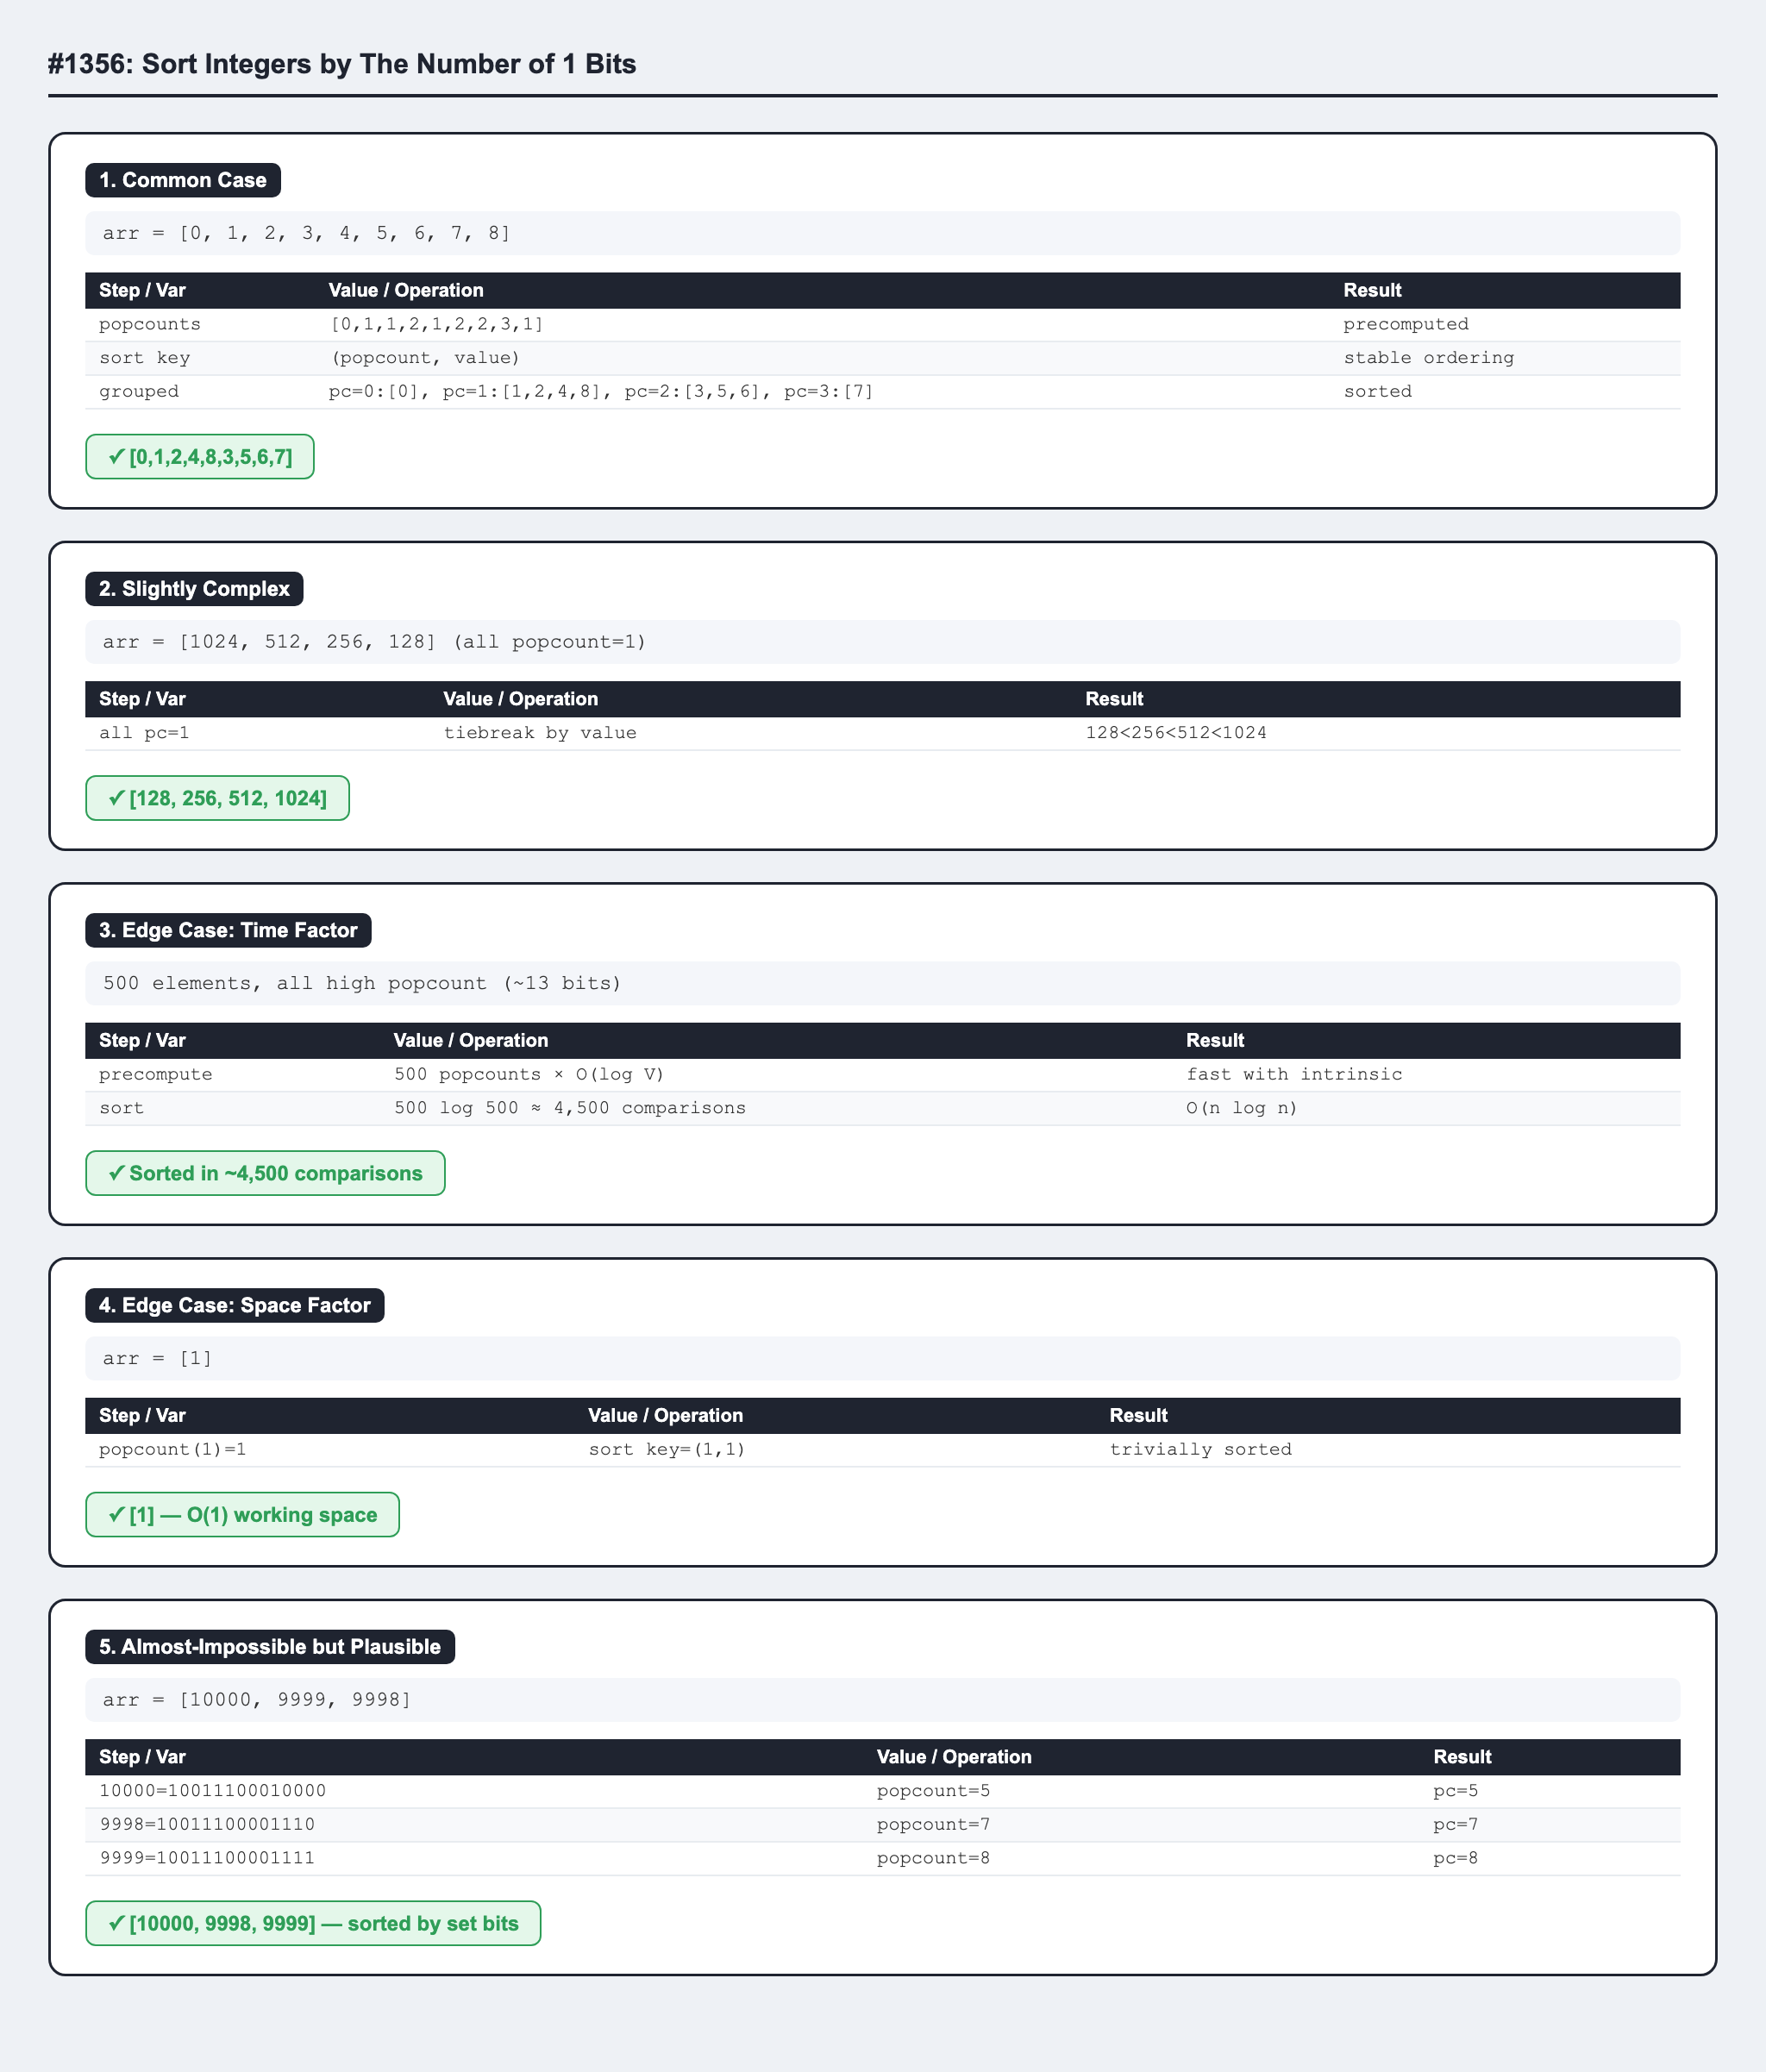